**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest


**Import dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving marketing_AB.csv.zip to marketing_AB.csv.zip


In [ ]:
import zipfile

with zipfile.ZipFile("marketing_AB.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("marketing_AB.csv")
df.head()



,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


**3. Data** **Cleaning**

In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()


,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
df["converted"] = df["converted"].astype(int)


**4. Basic Group Summary**

In [ ]:
group_summary = df.groupby("test_group")["converted"].agg(["count", "sum"])
group_summary["conversion_rate"] = group_summary["sum"] / group_summary["count"]
group_summary


,count,sum,conversion_rate
test_group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


**5. Visualize Conversion Rates**

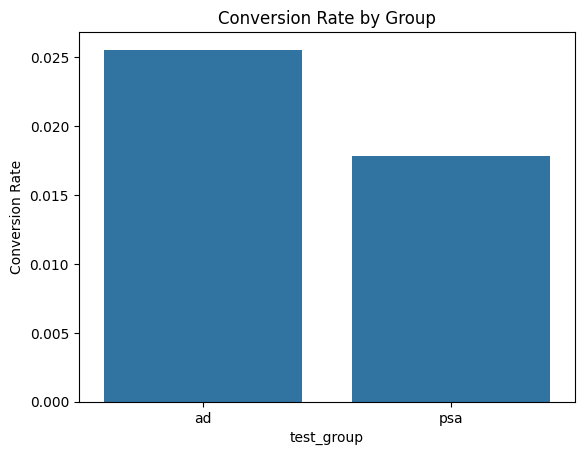

In [ ]:
sns.barplot(x=group_summary.index, y=group_summary["conversion_rate"])
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()


**6. Statistical Significance (Z-Test)**

In [ ]:
ad = df[df["test_group"] == "ad"]
psa = df[df["test_group"] == "psa"]

conversions = np.array([ad["converted"].sum(), psa["converted"].sum()])
observations = np.array([ad.shape[0], psa.shape[0]])

z_stat, p_value = proportions_ztest(conversions, observations)

print("Z-statistic:", z_stat)
print("P-value:", p_value)


Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [ ]:
if p_value < 0.05:
    print("Statistically significant difference ✅")
else:
    print("No statistically significant difference ❌")


Statistically significant difference ✅


**7. Estimate Revenue Impact**

In [ ]:
revenue_per_conversion = 10

ad_revenue = ad["converted"].sum() * revenue_per_conversion
psa_revenue = psa["converted"].sum() * revenue_per_conversion

incremental_revenue = ad_revenue - psa_revenue

print("Ad Revenue:", ad_revenue)
print("PSA Revenue:", psa_revenue)
print("Incremental Revenue from Ads:", incremental_revenue)


Ad Revenue: 144230
PSA Revenue: 4200
Incremental Revenue from Ads: 140030


**8. Conversion by Day**

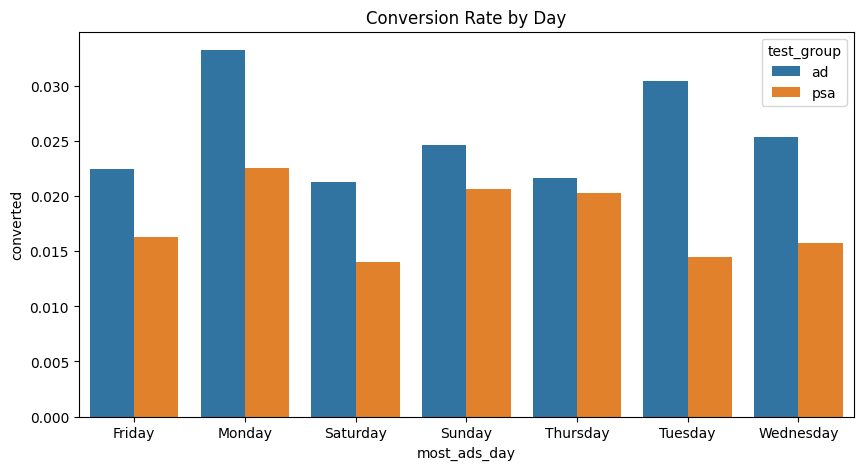

In [ ]:
day_conversion = df.groupby(["most_ads_day", "test_group"])["converted"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=day_conversion, x="most_ads_day", y="converted", hue="test_group")
plt.title("Conversion Rate by Day")
plt.show()


**9. Conversion by Hour**

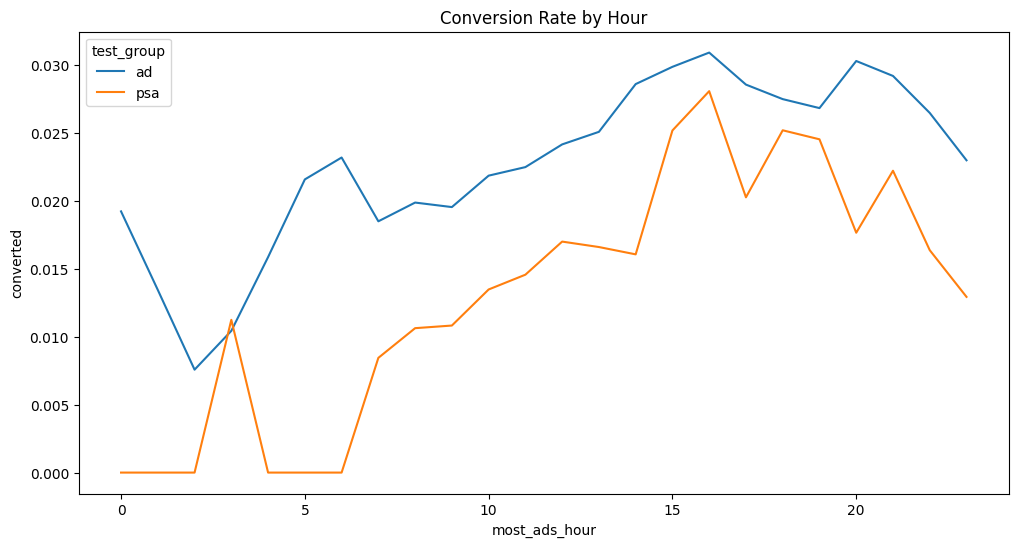

In [ ]:
hour_conversion = df.groupby(["most_ads_hour", "test_group"])["converted"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=hour_conversion, x="most_ads_hour", y="converted", hue="test_group")
plt.title("Conversion Rate by Hour")
plt.show()


**10. Ads Seen vs Conversion**

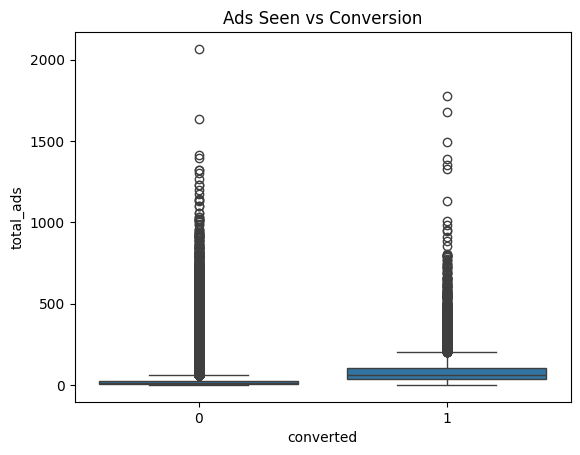

In [ ]:
sns.boxplot(x="converted", y="total_ads", data=df)
plt.title("Ads Seen vs Conversion")
plt.show()


**11. Answering the Business Questions**

In [ ]:
lift = group_summary.loc["ad", "conversion_rate"] - group_summary.loc["psa", "conversion_rate"]
print("Absolute Lift:", lift)

relative_lift = lift / group_summary.loc["psa", "conversion_rate"]
print("Relative Lift (%):", relative_lift * 100)


Absolute Lift: 0.007692453192201517
Relative Lift (%): 43.085064022225836


**Logistic Regression**

In [ ]:
import statsmodels.api as sm

df["group_binary"] = df["test_group"].map({"psa":0, "ad":1})

X = sm.add_constant(df[["group_binary", "total_ads"]])
y = df["converted"]

model = sm.Logit(y, X).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.108986
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588098
Method:                           MLE   Df Model:                            2
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                 0.07467
Time:                        00:48:41   Log-Likelihood:                -64095.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.4307      0.051    -86.695      0.000      -4.531      -4.330
group_binary     0.3894

The ad group showed a conversion rate of 2.55% compared to 1.79% in the PSA (control) group. The difference was statistically significant (Z = 7.37, p-value ≈ 1.71 × 10⁻¹³).

The ads generated an incremental lift of 0.76 percentage points in conversion, resulting in approximately $140,030 additional revenue.

Therefore, the campaign was successful, delivering both a significant increase in conversions and substantial incremental revenue.